# Visualize GMM-Mahalanobis Defense

This notebook visualizes the benign-labeled SHAP space used by the GMM defense. In the current pipeline that means clean benign rows plus poisoned benign rows. Malware overlay is optional and computed later from the backdoored model.

## Configure Paths

Change `ARTIFACT_DIR` and `GMM_DIR` to inspect a different run. The default points to the EMBER2018 `shap_largest_abs + min_population_new + problem_space_conservative` artifact.

In [60]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# ARTIFACT_DIR = PROJECT_ROOT / "results/ember/20%/random-defense/attack_artifacts/ember__lightgbm__shap_largest_abs__argmin_Nv_sum_abs_shap__problem_space_conservative"
# ARTIFACT_DIR = PROJECT_ROOT / "results/ember/20%/random-defense/attack_artifacts/ember__lightgbm__shap_largest_abs__min_population_new__problem_space_conservative"
ARTIFACT_DIR = PROJECT_ROOT / "results/ember/20%/random-defense/attack_artifacts/ember__lightgbm__combined_shap__combined_shap__problem_space_conservative"
PREPROCESS_DIR = ARTIFACT_DIR / "defense_preprocessing/standardized_pca50"
GMM_DIR = PREPROCESS_DIR / "gmm_defense/cov_diag_k1-10_reg1em06_remove1p"

MAX_SCATTER_POINTS = 30000
RANDOM_STATE = 42

print("PROJECT_ROOT:", PROJECT_ROOT)
print("ARTIFACT_DIR:", ARTIFACT_DIR)
print("PREPROCESS_DIR:", PREPROCESS_DIR)
print("GMM_DIR:", GMM_DIR)

PROJECT_ROOT: /Users/falcon/Machine Learning/Defense GMM-Maha
ARTIFACT_DIR: /Users/falcon/Machine Learning/Defense GMM-Maha/results/ember/20%/random-defense/attack_artifacts/ember__lightgbm__combined_shap__combined_shap__problem_space_conservative
PREPROCESS_DIR: /Users/falcon/Machine Learning/Defense GMM-Maha/results/ember/20%/random-defense/attack_artifacts/ember__lightgbm__combined_shap__combined_shap__problem_space_conservative/defense_preprocessing/standardized_pca50
GMM_DIR: /Users/falcon/Machine Learning/Defense GMM-Maha/results/ember/20%/random-defense/attack_artifacts/ember__lightgbm__combined_shap__combined_shap__problem_space_conservative/defense_preprocessing/standardized_pca50/gmm_defense/cov_diag_k1-10_reg1em06_remove1p


## Load Defense Outputs

`suspicious_scores.csv` already contains the GMM component, all Mahalanobis scores, true poison labels, and removal decisions for benign-labeled rows.

In [61]:
scores_path = GMM_DIR / "suspicious_scores.csv"
x_reduced_path = PREPROCESS_DIR / "X_shap_reduced.npy"
gmm_metadata_path = GMM_DIR / "gmm_defense_metadata.json"
artifact_metadata_path = ARTIFACT_DIR / "defense_metadata.json"

for path in [scores_path, x_reduced_path, gmm_metadata_path, artifact_metadata_path]:
    if not path.exists():
        raise FileNotFoundError(path)

scores = pd.read_csv(scores_path)
X_reduced = np.load(x_reduced_path, mmap_mode="r")
X2 = np.asarray(X_reduced[:len(scores), :2])

with open(gmm_metadata_path, "r", encoding="utf-8") as f:
    gmm_metadata = json.load(f)
with open(artifact_metadata_path, "r", encoding="utf-8") as f:
    artifact_metadata = json.load(f)

summary = {
    "rows_in_scores": len(scores),
    "X_shap_reduced_shape": tuple(X_reduced.shape),
    "poisoned_rows": int(scores["is_poisoned"].sum()),
    "clean_benign_rows": int((~scores["is_poisoned"].astype(bool)).sum()),
    "removed_rows": int(scores["removed"].sum()),
    "removed_poisoned_rows": int((scores["removed"] & scores["is_poisoned"]).sum()),
    "best_gmm": gmm_metadata.get("best_model"),
    "watermark_feature_count": len(artifact_metadata.get("watermark_features", [])),
}
display(pd.Series(summary, name="value"))
display(scores.head())

rows_in_scores                                                         82709
X_shap_reduced_shape                                             (82709, 50)
poisoned_rows                                                            600
clean_benign_rows                                                      82109
removed_rows                                                             828
removed_poisoned_rows                                                      5
best_gmm                   {'bic': 14634236.640610963, 'converged': True,...
watermark_feature_count                                                   17
Name: value, dtype: object

,benign_position,watermarked_idx,original_idx,source_idx,is_poisoned,component,local_mahalanobis,local_z,local_global_z,global_mahalanobis,global_z,removed
0,0,37291,0,0,False,3,28.088339,-0.565751,-0.843499,77.172123,0.396079,False
1,1,37292,1,1,False,3,37.102553,-0.333448,-0.493219,95.422453,0.662107,False
2,2,37293,2,2,False,0,55.848979,0.324106,0.235241,44.025205,-0.087092,False
3,3,37294,3,3,False,8,76.683208,1.479892,1.044831,85.659179,0.519791,False
4,4,37295,4,4,False,8,61.879672,0.666128,0.469586,52.159245,0.031475,False


## Component Enrichment

This table answers: which GMM components contain the poisoned benign rows?

In [62]:
component_summary = scores.groupby("component", sort=True).agg(
    rows=("component", "size"),
    poisoned=("is_poisoned", "sum"),
    removed=("removed", "sum"),
).reset_index()
removed_poisoned_by_component = scores[scores["removed"] & scores["is_poisoned"]].groupby("component").size()
component_summary["removed_poisoned"] = component_summary["component"].map(removed_poisoned_by_component).fillna(0).astype(int)
component_summary["poison_rate"] = component_summary["poisoned"] / component_summary["rows"]
component_summary["poison_share"] = component_summary["poisoned"] / max(int(scores["is_poisoned"].sum()), 1)
component_summary["removed_rate"] = component_summary["removed"] / component_summary["rows"]

display(component_summary.sort_values(["poisoned", "poison_rate"], ascending=False))

,component,rows,poisoned,removed,removed_poisoned,poison_rate,poison_share,removed_rate
0,0,26605,191,59,0,0.007179,0.318333,0.002218
2,2,14033,101,264,1,0.007197,0.168333,0.018813
3,3,13320,98,182,0,0.007357,0.163333,0.013664
4,4,11454,93,18,0,0.008119,0.155000,0.001572
8,8,7328,58,90,0,0.007915,0.096667,0.012282
1,1,3824,28,123,3,0.007322,0.046667,0.032165
9,9,3248,20,49,0,0.006158,0.033333,0.015086
7,7,2073,11,35,1,0.005306,0.018333,0.016884
5,5,583,0,8,0,0.000000,0.000000,0.013722
6,6,241,0,0,0,0.000000,0.000000,0.000000


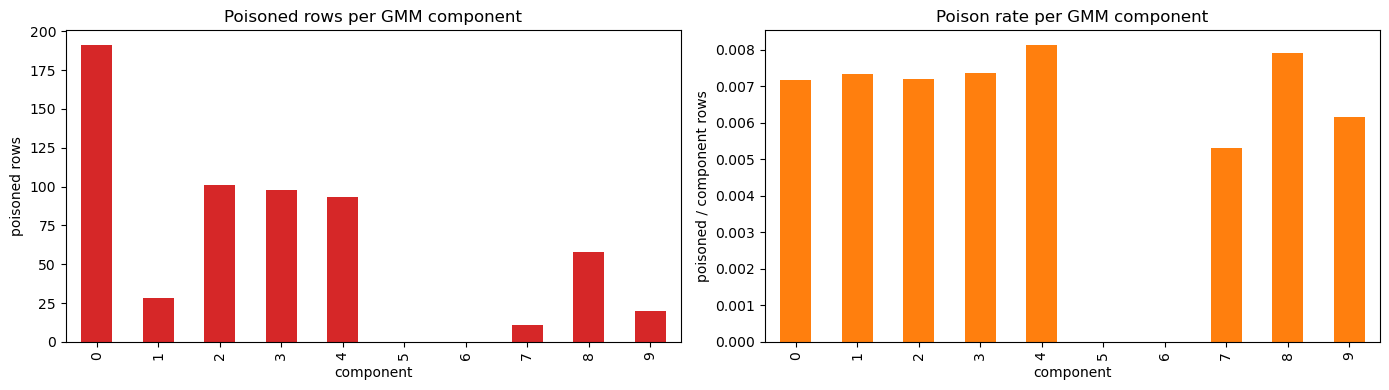

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
component_summary.sort_values("component").plot.bar(x="component", y="poisoned", ax=axes[0], color="tab:red", legend=False)
axes[0].set_title("Poisoned rows per GMM component")
axes[0].set_ylabel("poisoned rows")
component_summary.sort_values("component").plot.bar(x="component", y="poison_rate", ax=axes[1], color="tab:orange", legend=False)
axes[1].set_title("Poison rate per GMM component")
axes[1].set_ylabel("poisoned / component rows")
plt.tight_layout()

## Oracle vs Observable Component Diagnostics

This section intentionally uses `is_poisoned` only to name the poison-heavy components. Columns prefixed with `oracle_` are diagnostic-only. The other columns are observable from the fitted GMM and score table, so they are candidates for a real unsupervised component-level rule.

In [64]:
score_columns = ["local_z", "local_mahalanobis", "local_global_z", "global_z", "global_mahalanobis"]
total_poison = max(int(scores["is_poisoned"].sum()), 1)
global_poison_rate = float(scores["is_poisoned"].mean())

def q90(x):
    return x.quantile(0.90)

def q95(x):
    return x.quantile(0.95)

component_profile = scores.groupby("component", sort=True).agg(
    rows=("component", "size"),
    oracle_poisoned=("is_poisoned", "sum"),
    removed=("removed", "sum"),
)

removed_poisoned = scores[scores["removed"] & scores["is_poisoned"]].groupby("component").size()
component_profile["removed_poisoned"] = removed_poisoned.reindex(component_profile.index, fill_value=0).astype(int)
component_profile["removed_rate"] = component_profile["removed"] / component_profile["rows"]
component_profile["oracle_poison_rate"] = component_profile["oracle_poisoned"] / component_profile["rows"]
component_profile["oracle_poison_share"] = component_profile["oracle_poisoned"] / total_poison
component_profile["oracle_expected_poisoned_uniform"] = component_profile["rows"] * global_poison_rate
component_profile["oracle_excess_poisoned"] = component_profile["oracle_poisoned"] - component_profile["oracle_expected_poisoned_uniform"]
component_profile["oracle_lift_vs_uniform"] = component_profile["oracle_poison_rate"] / (global_poison_rate + 1e-12)

score_stats = scores.groupby("component", sort=True)[score_columns].agg(["mean", "median", "std", "max", q90, q95])
score_stats.columns = [f"{score}_{stat}" for score, stat in score_stats.columns]
component_profile = component_profile.join(score_stats)

for score_col in score_columns:
    for pct in (1, 5, 10):
        n = max(1, int(np.ceil(len(scores) * pct / 100.0)))
        threshold = scores[score_col].nlargest(n).min()
        top_mask = scores[score_col] >= threshold
        component_profile[f"frac_top{pct}p_{score_col}"] = top_mask.groupby(scores["component"]).mean()

component_profile = component_profile.reset_index()

display_cols = [
    "component", "rows", "oracle_poisoned", "oracle_poison_rate", "oracle_poison_share",
    "oracle_lift_vs_uniform", "oracle_excess_poisoned", "removed_rate",
    "global_z_mean", "global_z_q90", "global_z_max",
    "local_z_mean", "local_z_q90", "local_global_z_mean",
    "frac_top1p_global_z", "frac_top5p_global_z", "frac_top1p_local_z", "frac_top5p_local_z",
]
display(component_profile[display_cols].sort_values(["oracle_poisoned", "oracle_poison_rate"], ascending=False))

,component,rows,oracle_poisoned,oracle_poison_rate,oracle_poison_share,oracle_lift_vs_uniform,oracle_excess_poisoned,removed_rate,global_z_mean,global_z_q90,global_z_max,local_z_mean,local_z_q90,local_global_z_mean,frac_top1p_global_z,frac_top5p_global_z,frac_top1p_local_z,frac_top5p_local_z
0,0,26605,191,0.007179,0.318333,0.989627,-2.001971,0.002218,-0.146064,0.135950,0.635906,-2.152259e-16,1.440839,0.006330,0.000000,0.000000,0.002218,0.038451
2,2,14033,101,0.007197,0.168333,0.992139,-0.800288,0.018813,-0.408435,-0.249971,0.251645,-2.085080e-16,1.293746,0.004085,0.000000,0.000000,0.018813,0.051379
3,3,13320,98,0.007357,0.163333,1.014199,1.372063,0.013664,1.195226,2.216051,93.364858,1.832535e-16,0.630477,0.009572,0.058859,0.292417,0.013664,0.023198
4,4,11454,93,0.008119,0.155000,1.119250,9.908680,0.001572,-0.475432,-0.215442,0.027805,-2.486370e-16,1.528109,0.006742,0.000000,0.000000,0.001572,0.090449
8,8,7328,58,0.007915,0.096667,1.091048,4.840126,0.012282,0.032241,0.317744,1.270601,2.822524e-17,1.436472,-0.001296,0.000000,0.000000,0.012282,0.049263
1,1,3824,28,0.007322,0.046667,1.009350,0.259367,0.032165,-0.439272,-0.390026,-0.256959,-4.105270e-17,1.437704,0.006419,0.000000,0.000000,0.032165,0.070868
9,9,3248,20,0.006158,0.033333,0.848820,-3.562127,0.015086,-0.073949,0.250449,1.193663,1.096550e-16,1.354127,0.010078,0.000000,0.000000,0.015086,0.054803
7,7,2073,11,0.005306,0.018333,0.731467,-4.038267,0.016884,-0.281932,-0.251818,-0.230848,-3.197314e-17,2.091773,-0.007847,0.000000,0.000000,0.016884,0.110468
5,5,583,0,0.000000,0.000000,0.000000,-4.229286,0.013722,1.202859,1.232581,1.235069,-2.995507e-16,0.319336,0.007456,0.000000,0.000000,0.013722,0.013722
6,6,241,0,0.000000,0.000000,0.000000,-1.748298,0.000000,2.944685,2.944685,2.944685,0.000000e+00,0.000000,-1.934973,1.000000,1.000000,0.000000,0.000000


### Which Observable Component Properties Track Poison Concentration?

This table checks whether non-oracle component properties move together with poison concentration. A strong absolute Spearman value means the component property ranks components similarly to the oracle poison column. This is still diagnostic, because the correlation is evaluated with labels.

In [65]:
oracle_only_cols = {
    "oracle_poisoned", "oracle_poison_rate", "oracle_poison_share",
    "oracle_expected_poisoned_uniform", "oracle_excess_poisoned", "oracle_lift_vs_uniform",
    "removed_poisoned",
}

candidate_cols = []
for col in component_profile.columns:
    if col in {"component"} or col in oracle_only_cols:
        continue
    if pd.api.types.is_numeric_dtype(component_profile[col]):
        candidate_cols.append(col)

signal_rows = []
for col in candidate_cols:
    if component_profile[col].nunique(dropna=True) < 2:
        continue
    spearman_share = component_profile[[col, "oracle_poison_share"]].corr(method="spearman").iloc[0, 1]
    spearman_rate = component_profile[[col, "oracle_poison_rate"]].corr(method="spearman").iloc[0, 1]
    signal_rows.append({
        "observable_property": col,
        "spearman_poison_share": spearman_share,
        "abs_spearman_poison_share": abs(spearman_share),
        "spearman_poison_rate": spearman_rate,
        "abs_spearman_poison_rate": abs(spearman_rate),
    })

component_signal_df = pd.DataFrame(signal_rows).sort_values("abs_spearman_poison_share", ascending=False)
display(component_signal_df.head(25))

,observable_property,spearman_poison_share,abs_spearman_poison_share,spearman_poison_rate,abs_spearman_poison_rate
0,rows,0.996965,0.996965,0.656538,0.656538
1,removed,0.717329,0.717329,0.547115,0.547115
29,global_mahalanobis_std,0.638301,0.638301,0.674775,0.674775
23,global_z_std,0.638301,0.638301,0.674775,0.674775
10,local_mahalanobis_median,0.583589,0.583589,0.206688,0.206688
16,local_global_z_median,0.583589,0.583589,0.206688,0.206688
44,frac_top10p_global_z,-0.546608,0.546608,-0.390434,0.390434
47,frac_top10p_global_mahalanobis,-0.546608,0.546608,-0.390434,0.390434
5,local_z_std,-0.510641,0.510641,-0.170214,0.170214
28,global_mahalanobis_median,-0.462008,0.462008,-0.534957,0.534957


### Component-Level Rule Simulation

Here the ranking rule uses only observable properties, then the notebook evaluates the chosen components with the oracle labels afterward. If a rule catches poison-heavy components with reasonable precision, it may be worth turning into a real defense. If it only works when ranked by `oracle_` columns, then it is just cheating.

In [66]:
candidate_component_rules = [
    "global_z_mean", "global_z_q90", "global_z_max",
    "local_z_mean", "local_z_q90", "local_global_z_mean", "local_global_z_q90",
    "global_mahalanobis_mean", "global_mahalanobis_q90",
    "frac_top1p_global_z", "frac_top5p_global_z", "frac_top10p_global_z",
    "frac_top1p_local_z", "frac_top5p_local_z", "frac_top10p_local_z",
    "rows", "removed_rate",
]
candidate_component_rules = [col for col in candidate_component_rules if col in component_profile.columns]

rule_rows = []
max_components_to_flag = min(5, len(component_profile))
for rule_col in candidate_component_rules:
    ranked_components = component_profile.sort_values(rule_col, ascending=False)
    for top_n in range(1, max_components_to_flag + 1):
        selected = ranked_components.head(top_n)
        rows_flagged = int(selected["rows"].sum())
        poisoned_caught = int(selected["oracle_poisoned"].sum())
        rule_rows.append({
            "observable_rule": rule_col,
            "top_components": top_n,
            "component_ids": tuple(selected["component"].astype(int)),
            "rows_flagged": rows_flagged,
            "rows_flagged_percent": rows_flagged / len(scores),
            "poisoned_caught": poisoned_caught,
            "poison_recall": poisoned_caught / total_poison,
            "removal_precision": poisoned_caught / max(rows_flagged, 1),
        })

component_rule_df = pd.DataFrame(rule_rows)
display(component_rule_df.sort_values(["poison_recall", "removal_precision"], ascending=False).head(30))

,observable_rule,top_components,component_ids,rows_flagged,rows_flagged_percent,poisoned_caught,poison_recall,removal_precision
79,rows,5,"(0, 2, 3, 4, 8)",72740,0.879469,541,0.901667,0.007437
78,rows,4,"(0, 2, 3, 4)",65412,0.790869,483,0.805000,0.007384
49,frac_top1p_global_z,5,"(6, 3, 0, 1, 2)",58023,0.701532,418,0.696667,0.007204
54,frac_top5p_global_z,5,"(6, 3, 0, 1, 2)",58023,0.701532,418,0.696667,0.007204
77,rows,3,"(0, 2, 3)",53958,0.652384,390,0.650000,0.007228
24,local_z_q90,5,"(7, 4, 0, 1, 8)",51284,0.620053,381,0.635000,0.007429
74,frac_top10p_local_z,5,"(7, 0, 8, 4, 1)",51284,0.620053,381,0.635000,0.007429
73,frac_top10p_local_z,4,"(7, 0, 8, 4)",47460,0.573819,353,0.588333,0.007438
34,local_global_z_q90,5,"(7, 4, 1, 9, 0)",47204,0.570724,343,0.571667,0.007266
23,local_z_q90,4,"(7, 4, 0, 1)",43956,0.531454,323,0.538333,0.007348


### Component Signature Heatmap

The heatmap standardizes each column across components. The oracle column is included only as a reference target; a useful unsupervised signature should appear in the observable columns beside it.

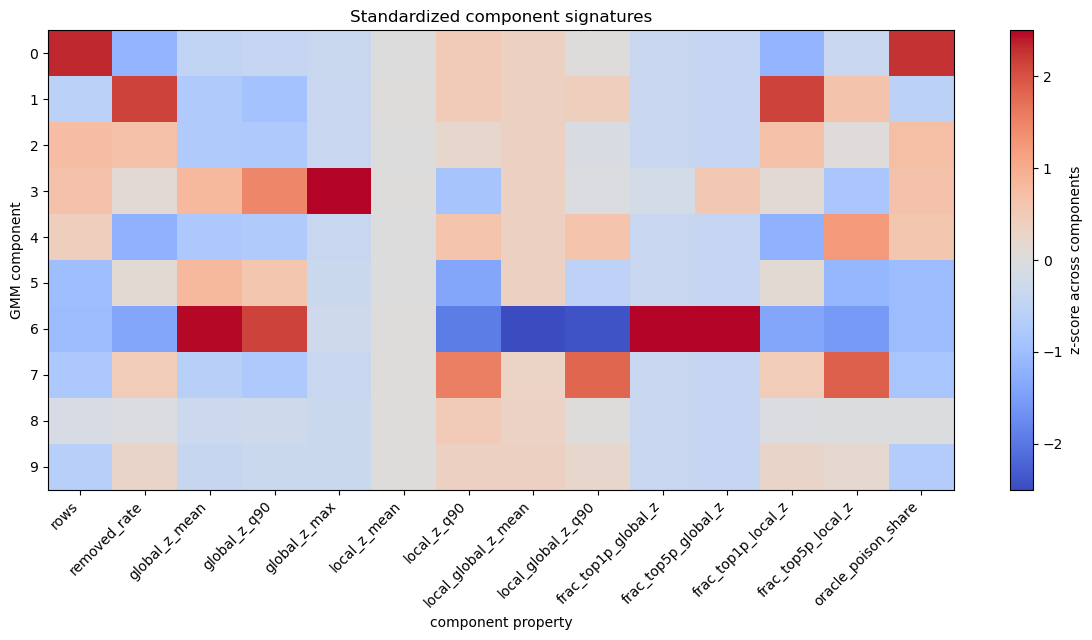

In [67]:
heat_cols = [
    "rows", "removed_rate",
    "global_z_mean", "global_z_q90", "global_z_max",
    "local_z_mean", "local_z_q90", "local_global_z_mean", "local_global_z_q90",
    "frac_top1p_global_z", "frac_top5p_global_z", "frac_top1p_local_z", "frac_top5p_local_z",
    "oracle_poison_share",
]
heat_cols = [col for col in heat_cols if col in component_profile.columns]
heat = component_profile.set_index("component")[heat_cols].astype(float)
heat_z = (heat - heat.mean(axis=0)) / (heat.std(axis=0, ddof=0) + 1e-12)

fig, ax = plt.subplots(figsize=(max(12, 0.8 * len(heat_cols)), max(4, 0.45 * len(heat_z) + 2)))
im = ax.imshow(heat_z, aspect="auto", cmap="coolwarm", vmin=-2.5, vmax=2.5)
ax.set_xticks(np.arange(len(heat_cols)))
ax.set_xticklabels(heat_cols, rotation=45, ha="right")
ax.set_yticks(np.arange(len(heat_z.index)))
ax.set_yticklabels(heat_z.index.astype(int))
ax.set_xlabel("component property")
ax.set_ylabel("GMM component")
ax.set_title("Standardized component signatures")
fig.colorbar(im, ax=ax, label="z-score across components")
plt.tight_layout()

## 2D Scatter: Clean Benign vs Poisoned Benign

The scatter uses the first two columns of `X_shap_reduced.npy`. With default preprocessing, these are the first two PCA dimensions after StandardScaler.

In [68]:
def sample_indices_for_scatter(df, max_points=30000, random_state=42):
    rng = np.random.default_rng(random_state)
    must_keep = (df["is_poisoned"].astype(bool) | df["removed"].astype(bool)).to_numpy()
    must_idx = np.flatnonzero(must_keep)
    rest_idx = np.flatnonzero(~must_keep)
    n_rest = max(0, max_points - len(must_idx))
    if len(rest_idx) > n_rest:
        rest_idx = rng.choice(rest_idx, size=n_rest, replace=False)
    return np.sort(np.concatenate([must_idx, rest_idx]))

plot_idx = sample_indices_for_scatter(scores, max_points=MAX_SCATTER_POINTS, random_state=RANDOM_STATE)
plot_scores = scores.iloc[plot_idx].copy()
plot_X2 = X2[plot_idx]
print("Scatter rows:", len(plot_idx), "of", len(scores))

Scatter rows: 30000 of 82709


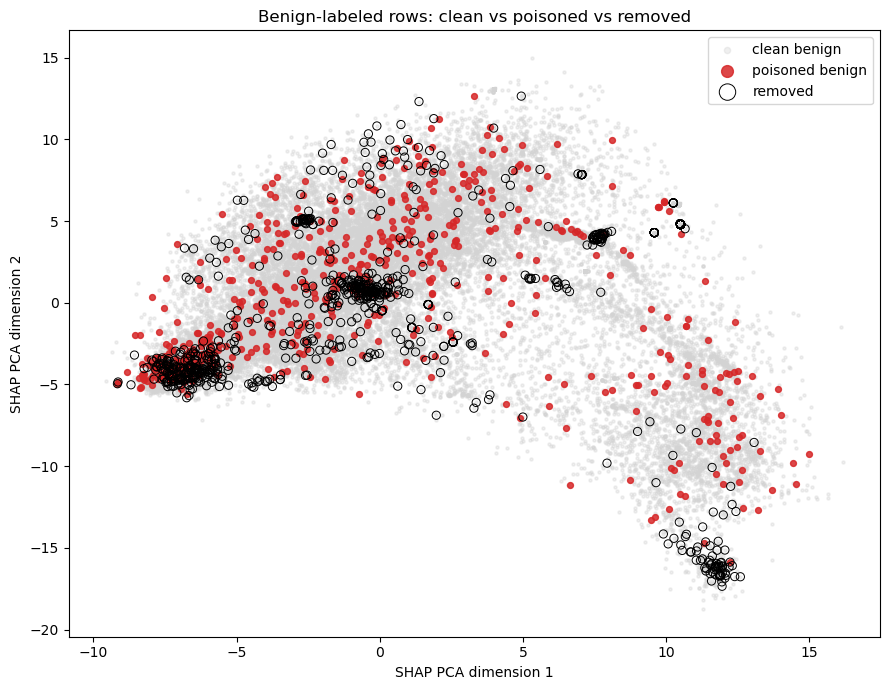

In [69]:
clean_mask = ~plot_scores["is_poisoned"].astype(bool).to_numpy()
poison_mask = plot_scores["is_poisoned"].astype(bool).to_numpy()
removed_mask = plot_scores["removed"].astype(bool).to_numpy()

plt.figure(figsize=(9, 7))
plt.scatter(plot_X2[clean_mask, 0], plot_X2[clean_mask, 1], s=5, c="lightgray", alpha=0.35, label="clean benign")
plt.scatter(plot_X2[poison_mask, 0], plot_X2[poison_mask, 1], s=18, c="tab:red", alpha=0.85, label="poisoned benign")
plt.scatter(plot_X2[removed_mask, 0], plot_X2[removed_mask, 1], s=35, facecolors="none", edgecolors="black", linewidths=0.7, label="removed")
plt.xlabel("SHAP PCA dimension 1")
plt.ylabel("SHAP PCA dimension 2")
plt.title("Benign-labeled rows: clean vs poisoned vs removed")
plt.legend(markerscale=2)
plt.tight_layout()

## 2D Scatter Colored by GMM Component

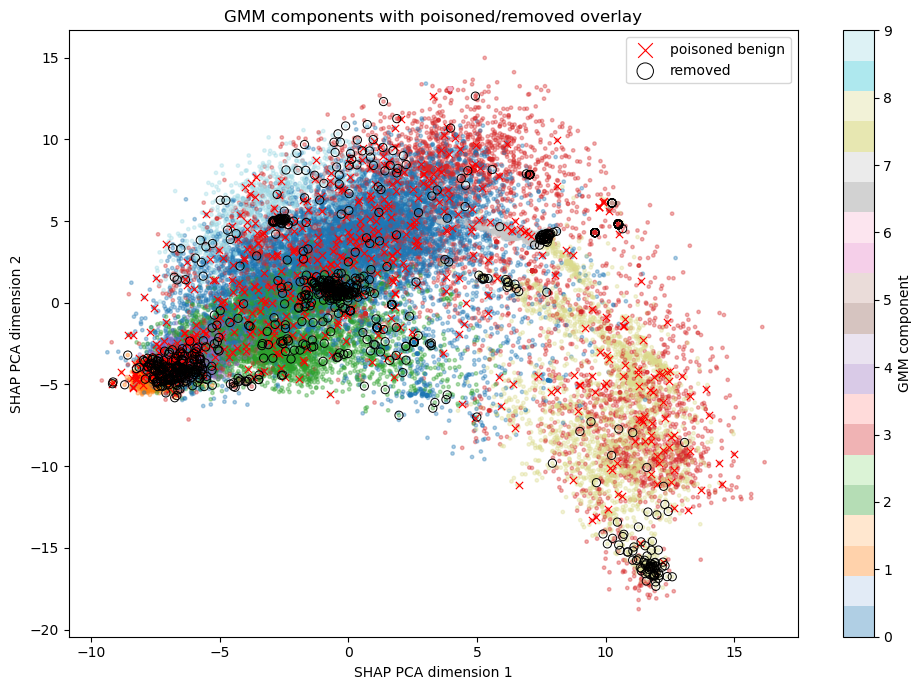

In [70]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(plot_X2[:, 0], plot_X2[:, 1], s=6, c=plot_scores["component"], cmap="tab20", alpha=0.35)
plt.scatter(plot_X2[poison_mask, 0], plot_X2[poison_mask, 1], s=28, c="red", marker="x", linewidths=0.8, label="poisoned benign")
plt.scatter(plot_X2[removed_mask, 0], plot_X2[removed_mask, 1], s=35, facecolors="none", edgecolors="black", linewidths=0.7, label="removed")
plt.colorbar(scatter, label="GMM component")
plt.xlabel("SHAP PCA dimension 1")
plt.ylabel("SHAP PCA dimension 2")
plt.title("GMM components with poisoned/removed overlay")
plt.legend(markerscale=2)
plt.tight_layout()

## Score Distributions

These histograms show whether a score separates poisoned benign rows from clean benign rows. If poisoned and clean distributions overlap strongly, that score will struggle as a detector.

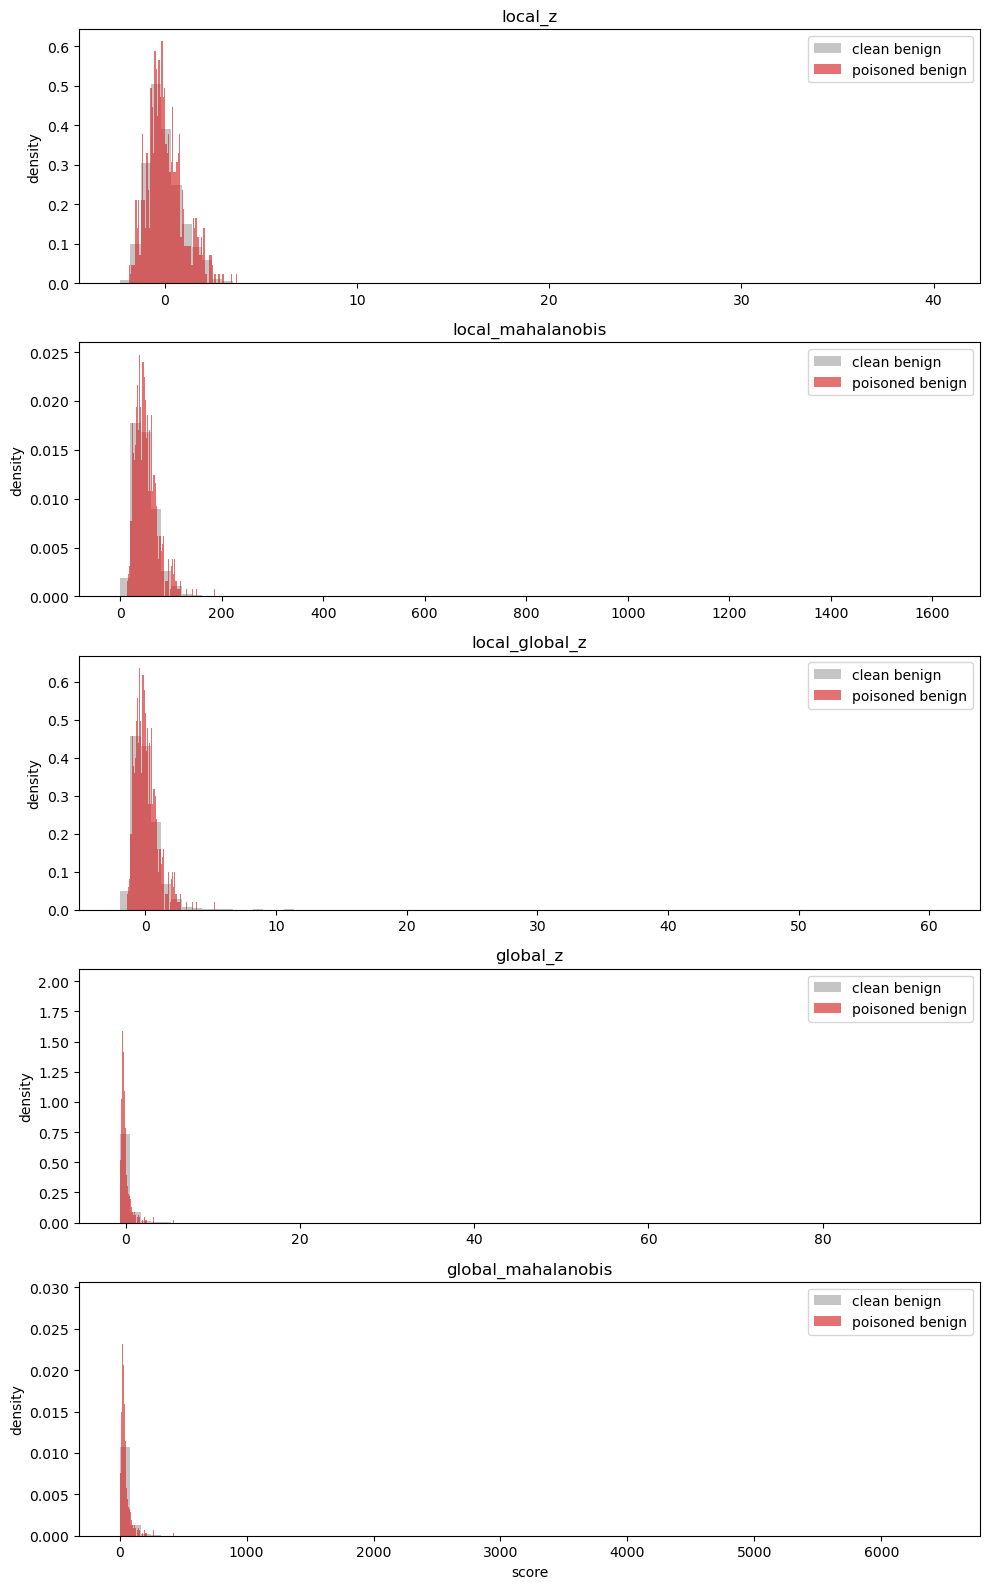

In [71]:
score_columns = ["local_z", "local_mahalanobis", "local_global_z", "global_z", "global_mahalanobis"]

fig, axes = plt.subplots(len(score_columns), 1, figsize=(10, 3.2 * len(score_columns)))
for ax, score_col in zip(axes, score_columns):
    clean_values = scores.loc[~scores["is_poisoned"].astype(bool), score_col]
    poison_values = scores.loc[scores["is_poisoned"].astype(bool), score_col]
    ax.hist(clean_values, bins=80, density=True, alpha=0.45, color="gray", label="clean benign")
    ax.hist(poison_values, bins=80, density=True, alpha=0.65, color="tab:red", label="poisoned benign")
    ax.set_title(score_col)
    ax.set_ylabel("density")
    ax.legend()
axes[-1].set_xlabel("score")
plt.tight_layout()

## Recall-at-K by Score

This answers: if we removed the top 1%, 2%, 5%, etc. by each score, how many poisoned rows would we catch?

In [72]:
percentages = np.array([0.5, 1, 2, 3, 5, 10, 15, 20, 30], dtype=float)
total_poison = max(int(scores["is_poisoned"].sum()), 1)

rows = []
for score_col in score_columns:
    ordered = scores.sort_values(score_col, ascending=False)
    for pct in percentages:
        n = max(1, int(np.ceil(len(scores) * pct / 100.0)))
        top = ordered.head(n)
        caught = int(top["is_poisoned"].sum())
        rows.append({
            "score": score_col,
            "top_percent": pct,
            "rows_removed": n,
            "poisoned_caught": caught,
            "poison_recall": caught / total_poison,
            "removal_precision": caught / n,
        })

recall_df = pd.DataFrame(rows)
display(recall_df.pivot(index="top_percent", columns="score", values="poisoned_caught"))
display(recall_df.pivot(index="top_percent", columns="score", values="poison_recall"))

score,global_mahalanobis,global_z,local_global_z,local_mahalanobis,local_z
top_percent,,,,,
0.5,1,1,3,3,3
1.0,3,3,4,4,5
2.0,7,7,7,7,10
3.0,14,14,28,28,14
5.0,23,23,39,39,32
10.0,49,49,71,71,67
15.0,81,81,94,94,89
20.0,110,110,128,128,122
30.0,154,154,197,197,196


score,global_mahalanobis,global_z,local_global_z,local_mahalanobis,local_z
top_percent,,,,,
0.5,0.001667,0.001667,0.005000,0.005000,0.005000
1.0,0.005000,0.005000,0.006667,0.006667,0.008333
2.0,0.011667,0.011667,0.011667,0.011667,0.016667
3.0,0.023333,0.023333,0.046667,0.046667,0.023333
5.0,0.038333,0.038333,0.065000,0.065000,0.053333
10.0,0.081667,0.081667,0.118333,0.118333,0.111667
15.0,0.135000,0.135000,0.156667,0.156667,0.148333
20.0,0.183333,0.183333,0.213333,0.213333,0.203333
30.0,0.256667,0.256667,0.328333,0.328333,0.326667


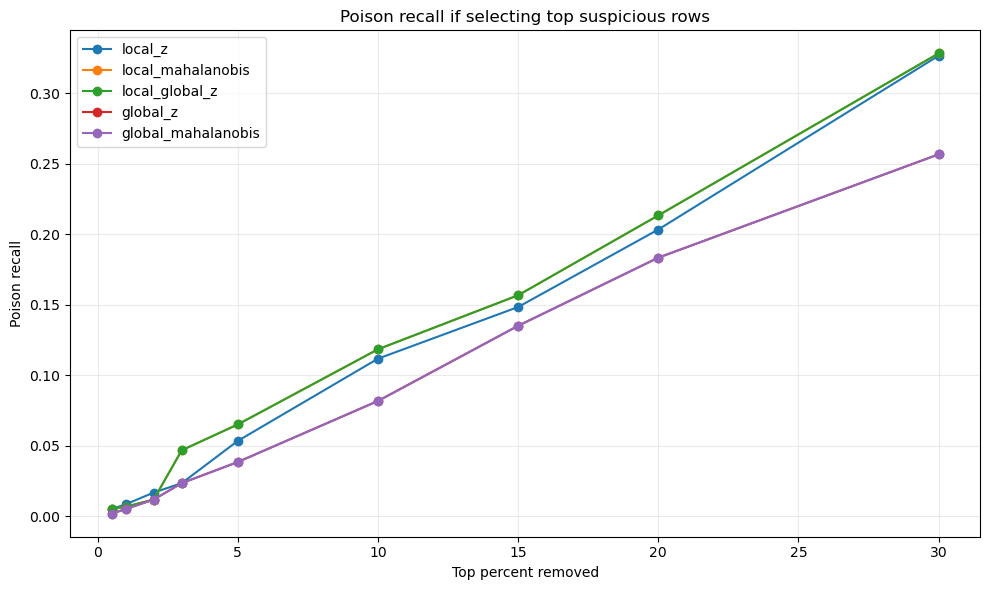

In [73]:
plt.figure(figsize=(10, 6))
for score_col in score_columns:
    part = recall_df[recall_df["score"] == score_col]
    plt.plot(part["top_percent"], part["poison_recall"], marker="o", label=score_col)
plt.xlabel("Top percent removed")
plt.ylabel("Poison recall")
plt.title("Poison recall if selecting top suspicious rows")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

## Rank Plot

Choose a score and inspect how early poisoned rows appear when sorted by suspiciousness.

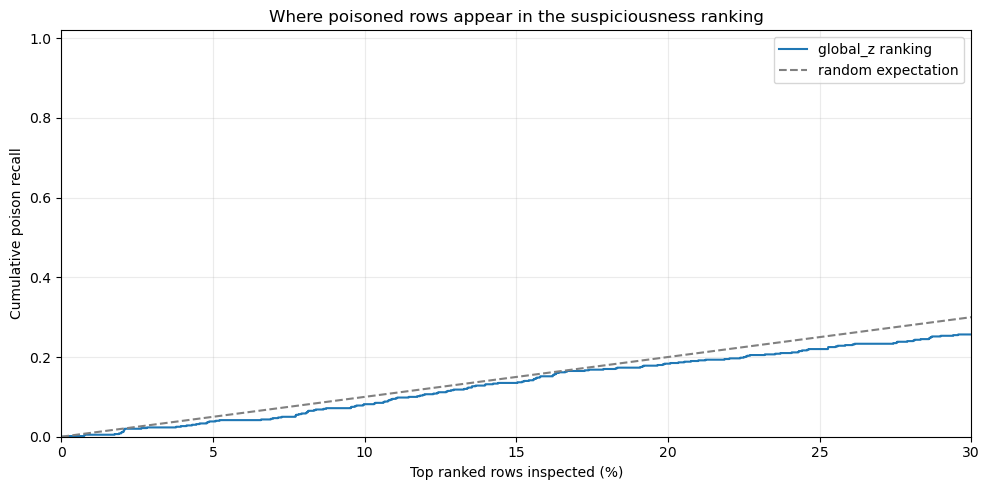

In [74]:
RANK_SCORE = "global_z"  # try: local_z, global_z, local_mahalanobis, global_mahalanobis

ranked = scores.sort_values(RANK_SCORE, ascending=False).reset_index(drop=True)
ranked["rank_percent"] = (np.arange(len(ranked)) + 1) / len(ranked) * 100
ranked["cumulative_poisoned"] = ranked["is_poisoned"].cumsum()
ranked["cumulative_poison_recall"] = ranked["cumulative_poisoned"] / total_poison

plt.figure(figsize=(10, 5))
plt.plot(ranked["rank_percent"], ranked["cumulative_poison_recall"], label=f"{RANK_SCORE} ranking")
plt.plot([0, 100], [0, 1], linestyle="--", color="gray", label="random expectation")
plt.xlim(0, 30)
plt.ylim(0, 1.02)
plt.xlabel("Top ranked rows inspected (%)")
plt.ylabel("Cumulative poison recall")
plt.title("Where poisoned rows appear in the suspiciousness ranking")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

## Nonlinear 2D Projection: UMAP or t-SNE

This projects the full 50D `X_shap_reduced` representation into 2D for visualization. It is only a visualization lens; the GMM/Mahalanobis scores above were still computed in the full reduced space. UMAP is used if `umap-learn` is installed; otherwise this falls back to scikit-learn t-SNE. If it falls back to t-SNE, keep the sample size small.

The cell samples clean benign rows but keeps all poisoned and removed rows, so rare poisoned points are not accidentally dropped.

In [75]:
RUN_NONLINEAR_PROJECTION = False
NONLINEAR_METHOD = "auto"  # auto, umap, or tsne
MAX_NONLINEAR_POINTS = 1500
TSNE_MAX_ITER = 500

nonlinear_idx = sample_indices_for_scatter(scores, max_points=MAX_NONLINEAR_POINTS, random_state=RANDOM_STATE)
nonlinear_scores = scores.iloc[nonlinear_idx].copy()
X_nonlinear = np.asarray(X_reduced[nonlinear_idx], dtype="float32")

print("Nonlinear projection rows:", X_nonlinear.shape[0], "dimensions:", X_nonlinear.shape[1])
print("Poisoned rows kept:", int(nonlinear_scores["is_poisoned"].sum()))
print("Removed rows kept:", int(nonlinear_scores["removed"].sum()))

Nonlinear projection rows: 1500 dimensions: 50
Poisoned rows kept: 600
Removed rows kept: 828


In [76]:
def compute_nonlinear_embedding(X, method="auto", random_state=42, tsne_max_iter=500):
    method = method.lower()
    if method not in {"auto", "umap", "tsne"}:
        raise ValueError("method must be auto, umap, or tsne")

    if method in {"auto", "umap"}:
        try:
            import umap
            reducer = umap.UMAP(
                n_components=2,
                n_neighbors=30,
                min_dist=0.05,
                metric="euclidean",
                random_state=random_state,
            )
            return reducer.fit_transform(X), "umap"
        except ImportError:
            if method == "umap":
                raise
            print("umap-learn is not installed; falling back to sklearn t-SNE.")

    from sklearn.manifold import TSNE
    perplexity = min(30, max(5, (X.shape[0] - 1) // 3))
    kwargs = dict(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=random_state,
        verbose=1,
    )
    try:
        embedding = TSNE(max_iter=tsne_max_iter, **kwargs).fit_transform(X)
    except TypeError:
        embedding = TSNE(n_iter=tsne_max_iter, **kwargs).fit_transform(X)
    return embedding, "tsne"

if RUN_NONLINEAR_PROJECTION:
    nonlinear_embedding, nonlinear_method_used = compute_nonlinear_embedding(
        X_nonlinear,
        method=NONLINEAR_METHOD,
        random_state=RANDOM_STATE,
        tsne_max_iter=TSNE_MAX_ITER,
    )
    print("Projection method used:", nonlinear_method_used)
else:
    nonlinear_embedding, nonlinear_method_used = None, None
    print("Set RUN_NONLINEAR_PROJECTION = True to compute UMAP/t-SNE.")

Set RUN_NONLINEAR_PROJECTION = True to compute UMAP/t-SNE.


In [77]:
if nonlinear_embedding is not None:
    nl_clean = ~nonlinear_scores["is_poisoned"].astype(bool).to_numpy()
    nl_poison = nonlinear_scores["is_poisoned"].astype(bool).to_numpy()
    nl_removed = nonlinear_scores["removed"].astype(bool).to_numpy()

    plt.figure(figsize=(9, 7))
    plt.scatter(nonlinear_embedding[nl_clean, 0], nonlinear_embedding[nl_clean, 1], s=6, c="lightgray", alpha=0.35, label="clean benign")
    plt.scatter(nonlinear_embedding[nl_poison, 0], nonlinear_embedding[nl_poison, 1], s=18, c="tab:red", alpha=0.85, label="poisoned benign")
    plt.scatter(nonlinear_embedding[nl_removed, 0], nonlinear_embedding[nl_removed, 1], s=35, facecolors="none", edgecolors="black", linewidths=0.7, label="removed")
    plt.xlabel(f"{nonlinear_method_used.upper()} dimension 1")
    plt.ylabel(f"{nonlinear_method_used.upper()} dimension 2")
    plt.title(f"{nonlinear_method_used.upper()} projection of 50D SHAP/PCA space")
    plt.legend(markerscale=2)
    plt.tight_layout()

    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(nonlinear_embedding[:, 0], nonlinear_embedding[:, 1], s=7, c=nonlinear_scores["component"], cmap="tab20", alpha=0.45)
    plt.scatter(nonlinear_embedding[nl_poison, 0], nonlinear_embedding[nl_poison, 1], s=28, c="red", marker="x", linewidths=0.8, label="poisoned benign")
    plt.colorbar(scatter, label="GMM component")
    plt.xlabel(f"{nonlinear_method_used.upper()} dimension 1")
    plt.ylabel(f"{nonlinear_method_used.upper()} dimension 2")
    plt.title(f"{nonlinear_method_used.upper()} projection colored by GMM component")
    plt.legend(markerscale=2)
    plt.tight_layout()
else:
    print("No nonlinear embedding to plot.")

No nonlinear embedding to plot.


## Optional: Overlay Watermarked Malware

The defense pipeline is benign-only by default. This optional cell computes SHAP for watermarked malware using the saved backdoored model, applies the same scaler/PCA, and overlays it on the benign plot. Set `RUN_WATERMARKED_MALWARE_OVERLAY = True` to run it. It can be slow on large test sets, so it samples rows by default.

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator IncrementalPCA from version 1.5.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


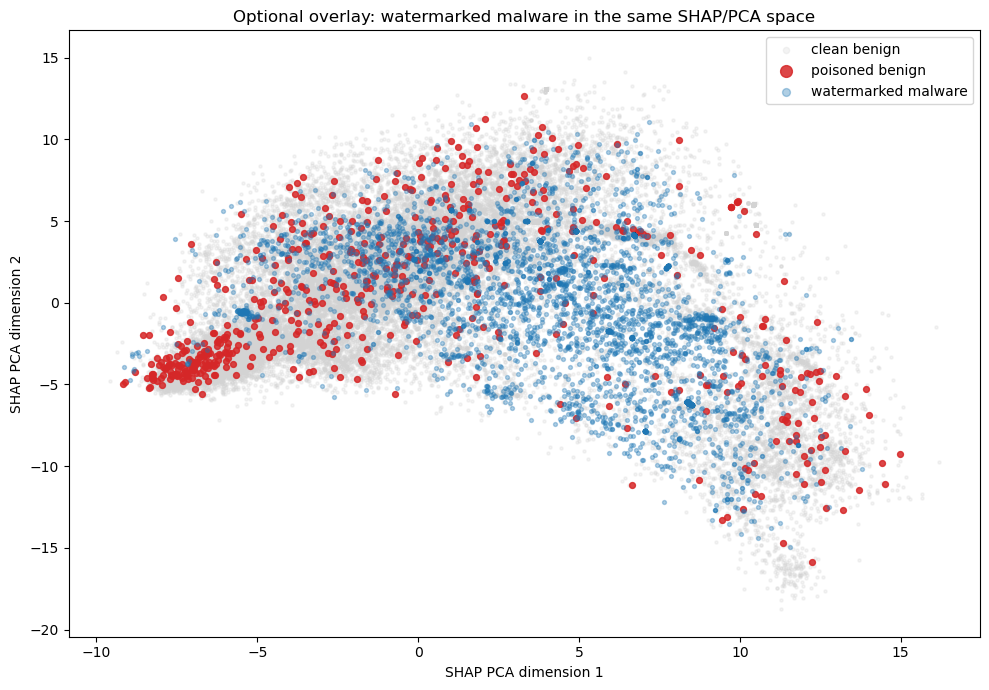

In [78]:
RUN_WATERMARKED_MALWARE_OVERLAY = True
MAX_MALWARE_OVERLAY_ROWS = 5000

if RUN_WATERMARKED_MALWARE_OVERLAY:
    import lightgbm as lgb
    import joblib
    model_paths = sorted(ARTIFACT_DIR.glob("*_backdoored"))
    if not model_paths:
        raise FileNotFoundError("No *_backdoored model file found in ARTIFACT_DIR")
    x_wm_mw_path = ARTIFACT_DIR / "watermarked_X_test.npy"
    if not x_wm_mw_path.exists():
        raise FileNotFoundError(x_wm_mw_path)

    X_wm_mw = np.load(x_wm_mw_path, mmap_mode="r")
    rng = np.random.default_rng(RANDOM_STATE)
    if X_wm_mw.shape[0] > MAX_MALWARE_OVERLAY_ROWS:
        malware_idx = np.sort(rng.choice(X_wm_mw.shape[0], size=MAX_MALWARE_OVERLAY_ROWS, replace=False))
    else:
        malware_idx = np.arange(X_wm_mw.shape[0])

    backdoored_model = lgb.Booster(model_file=str(model_paths[0]))
    contrib = np.asarray(backdoored_model.predict(X_wm_mw[malware_idx], pred_contrib=True))[:, :-1].astype("float32")
    scaler = joblib.load(PREPROCESS_DIR / "standard_scaler.joblib")
    Z = scaler.transform(contrib)
    pca_path = PREPROCESS_DIR / "pca.joblib"
    if pca_path.exists():
        Z = joblib.load(pca_path).transform(Z)
    malware_X2 = np.asarray(Z[:, :2])

    plt.figure(figsize=(10, 7))
    plt.scatter(plot_X2[clean_mask, 0], plot_X2[clean_mask, 1], s=5, c="lightgray", alpha=0.25, label="clean benign")
    plt.scatter(plot_X2[poison_mask, 0], plot_X2[poison_mask, 1], s=18, c="tab:red", alpha=0.85, label="poisoned benign")
    plt.scatter(malware_X2[:, 0], malware_X2[:, 1], s=8, c="tab:blue", alpha=0.35, label="watermarked malware")
    plt.xlabel("SHAP PCA dimension 1")
    plt.ylabel("SHAP PCA dimension 2")
    plt.title("Optional overlay: watermarked malware in the same SHAP/PCA space")
    plt.legend(markerscale=2)
    plt.tight_layout()
else:
    print("Set RUN_WATERMARKED_MALWARE_OVERLAY = True to compute and plot watermarked malware overlay.")